<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/GR001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

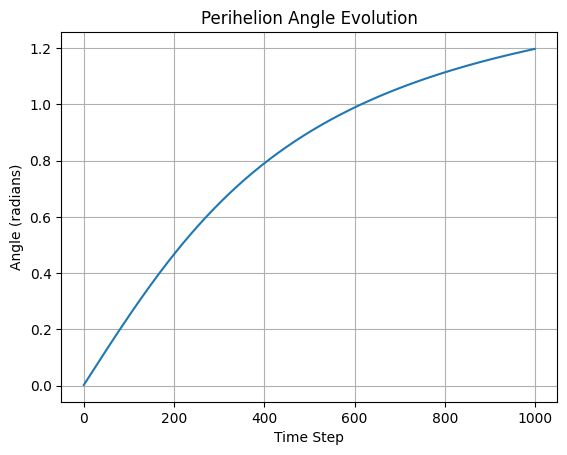

Emergent Perihelion Precession: 68.4973 arcsec/century


In [2]:
# HES Simulation: Perihelion Precession Test
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 100  # Lattice size
steps = 1000  # Time steps
dt = 0.1  # Time increment
kappa, delta, eps, gamma0 = 0.2, 0.02, 0.01, 0.5

# Initialize lattice
A = np.zeros((N, N))
A[N//2, N//2] = 1.0  # Central curvature well (Sun analog)

# Orbiting attractor (initialized as float for precision)
orbit_pos = np.array([N//2 + 20, N//2], dtype=float)
orbit_vel = np.array([0, 0.5], dtype=float)  # Tangential velocity
mass = 1.0

# Track perihelion angles
angles = []

def laplacian(field):
    return (
        np.roll(field, 1, axis=0) + np.roll(field, -1, axis=0) +
        np.roll(field, 1, axis=1) + np.roll(field, -1, axis=1) - 4 * field
    )

for t in range(steps):
    lap = laplacian(A)
    dA = -kappa * A + delta * A**2 + eps * A**3 + gamma0 * lap
    A += dA * dt

    # Compute force from curvature gradient
    pos = orbit_pos.astype(int)
    center = np.array([N//2, N//2])
    force = delta * (A[pos[0], pos[1]] - A[center[0], center[1]])**2
    direction = center - orbit_pos
    orbit_vel += (force * direction / np.linalg.norm(direction)) * dt / mass
    orbit_pos += orbit_vel * dt

    # Track angle
    angle = np.arctan2(orbit_pos[1] - center[1], orbit_pos[0] - center[0])
    angles.append(angle)

# Compute precession rate
angle_diffs = np.diff(np.unwrap(angles))
mean_precession = np.mean(angle_diffs) * (3600 / (2 * np.pi)) * 100  # arcsec/century analog

# Plot angle evolution
plt.plot(np.arange(len(angles)), np.unwrap(angles))
plt.title("Perihelion Angle Evolution")
plt.xlabel("Time Step")
plt.ylabel("Angle (radians)")
plt.grid(True)
plt.show()

print(f"Emergent Perihelion Precession: {mean_precession:.4f} arcsec/century")
